# 1. Objective

Tune the current strongest non-embedding feature set. EfficientNet-B0 experiments did not improve validation, so this notebook focuses on ExtraTrees tuning, HGB tuning, simple OOF blending, biomass constraint validation, and hard-segment diagnostics.

Target benchmark to beat: the current stable baseline constrained weighted R2 is about `0.81160`.

In [1]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageStat
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)

sns.set_theme(style='whitegrid', palette='viridis', rc={
    'figure.figsize': (11, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

DATA_DIR = Path('/kaggle/input/competitions/csiro-biomass')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_ORDER = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
TARGET_WEIGHTS = {
    'Dry_Green_g': 0.1,
    'Dry_Dead_g': 0.1,
    'Dry_Clover_g': 0.1,
    'GDM_g': 0.2,
    'Dry_Total_g': 0.5,
}

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Expected Kaggle input at {DATA_DIR}')

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Data directory: /kaggle/input/competitions/csiro-biomass
Output directory: /kaggle/working


# 2. Data and Validation

## 2.1 Load Competition Files

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'train: {train.shape} | train images: {train.image_path.nunique():,}')
print(f'test: {test.shape} | test images: {test.image_path.nunique():,}')
print(f'sample_submission: {sample_submission.shape}')
display(train.head())
display(test.head())

train: (1785, 9) | train images: 357
test: (5, 3) | test images: 1
sample_submission: (5, 2)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


## 2.2 Metric and Grouped Folds

In [3]:
def weighted_r2_score(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weighted_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * np.square(y_true - y_pred))
    ss_tot = np.sum(weights * np.square(y_true - weighted_mean))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

train = train.copy()
train['target_weight'] = train['target_name'].map(TARGET_WEIGHTS)

gkf = GroupKFold(n_splits=5)
train['fold'] = -1
for fold, (_, val_idx) in enumerate(gkf.split(train, groups=train['image_path']), start=1):
    train.loc[val_idx, 'fold'] = fold

display(pd.crosstab(train['fold'], train['target_name']))

target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
fold,,,,,
1,72,72,72,72,72
2,72,72,72,72,72
3,71,71,71,71,71
4,71,71,71,71,71
5,71,71,71,71,71


# 3. Feature Frame

## 3.1 Image-Level Targets and Metadata

In [4]:
meta_cols = ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'fold']
image_meta = train[meta_cols].drop_duplicates('image_path').copy()
image_targets = train.pivot_table(index='image_path', columns='target_name', values='target', aggfunc='first').reset_index()
image_train = image_meta.merge(image_targets, on='image_path', how='left')

test_image = test.drop_duplicates('image_path').copy()
for col in ['Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']:
    if col not in test_image.columns:
        test_image[col] = np.nan

print(image_train.shape, test_image.shape)
display(image_train.head())

(357, 12) (1, 8)


,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,1,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,5,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,4,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,3,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,2,0.4343,23.2239,10.5261,34.1844,10.9605


## 3.2 Metadata Features

In [5]:
def add_metadata_features(df):
    out = df.copy()
    dates = pd.to_datetime(out.get('Sampling_Date'), errors='coerce')
    out['sample_month'] = dates.dt.month
    out['sample_dayofyear'] = dates.dt.dayofyear
    out['sample_year'] = dates.dt.year
    species = out['Species'].fillna('Unknown').astype(str)
    out['primary_species'] = species.str.split('_').str[0]
    out['species_count'] = np.where(species.eq('Unknown'), 0, species.str.count('_') + 1)
    out['ndvi_x_height'] = out['Pre_GSHH_NDVI'] * out['Height_Ave_cm']
    out['height_log1p'] = np.log1p(out['Height_Ave_cm'].clip(lower=0))
    return out

image_train = add_metadata_features(image_train)
test_image = add_metadata_features(test_image)

## 3.3 Image Color Features

In [6]:
def extract_image_features(df, cache_name):
    cache_path = OUTPUT_DIR / cache_name
    if cache_path.exists():
        print(f'Loading cached features: {cache_path}')
        return pd.read_csv(cache_path)

    rows = []
    for rel_path in tqdm(df['image_path'].drop_duplicates().tolist(), desc=cache_name):
        path = DATA_DIR / rel_path
        row = {'image_path': rel_path}
        try:
            img = Image.open(path).convert('RGB')
            row['width'], row['height'] = img.size
            small = img.resize((256, 256))
            arr = np.asarray(small, dtype=np.float32) / 255.0
            stat = ImageStat.Stat(small)
            for idx, ch in enumerate(['r', 'g', 'b']):
                row[f'{ch}_mean'] = stat.mean[idx] / 255.0
                row[f'{ch}_std'] = stat.stddev[idx] / 255.0
                row[f'{ch}_p10'] = np.quantile(arr[:, :, idx], 0.10)
                row[f'{ch}_p50'] = np.quantile(arr[:, :, idx], 0.50)
                row[f'{ch}_p90'] = np.quantile(arr[:, :, idx], 0.90)
            red, green, blue = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
            row['brightness'] = arr.mean()
            row['contrast'] = arr.std()
            row['excess_green'] = np.mean(2 * green - red - blue)
            row['green_red_ratio'] = np.mean(green / (red + 1e-4))
            row['visible_ndvi_proxy'] = np.mean((green - red) / (green + red + 1e-4))
        except Exception as exc:
            row['image_error'] = str(exc)
        rows.append(row)

    features = pd.DataFrame(rows)
    features.to_csv(cache_path, index=False)
    print(f'Wrote {cache_path}')
    return features

train_img = extract_image_features(image_train, 'train_image_features.csv')
test_img = extract_image_features(test_image, 'test_image_features.csv')

image_train = image_train.merge(train_img, on='image_path', how='left')
test_image = test_image.merge(test_img, on='image_path', how='left')
print(f'Image feature columns: {len([c for c in train_img.columns if c != "image_path"])}')

train_image_features.csv:   0%|          | 0/357 [00:00<?, ?it/s]

Wrote /kaggle/working/train_image_features.csv


test_image_features.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Wrote /kaggle/working/test_image_features.csv
Image feature columns: 22


## 3.4 Long-Format Training Table

In [7]:
def to_long(df, include_targets=True):
    repeated = []
    for target_name in TARGET_ORDER:
        tmp = df.copy()
        tmp['target_name'] = target_name
        tmp['target_weight'] = TARGET_WEIGHTS[target_name]
        if include_targets:
            tmp['target'] = tmp[target_name]
        repeated.append(tmp)
    return pd.concat(repeated, ignore_index=True)

train_long = to_long(image_train, include_targets=True)

tabular_color_cols = [
    'target_name', 'State', 'Species', 'primary_species', 'species_count',
    'Pre_GSHH_NDVI', 'Height_Ave_cm', 'ndvi_x_height', 'height_log1p',
    'sample_month', 'sample_dayofyear', 'sample_year',
    'width', 'height', 'brightness', 'contrast', 'excess_green', 'green_red_ratio', 'visible_ndvi_proxy',
    'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std',
    'r_p10', 'r_p50', 'r_p90', 'g_p10', 'g_p50', 'g_p90', 'b_p10', 'b_p50', 'b_p90',
]
tabular_color_cols = [c for c in tabular_color_cols if c in train_long.columns]
cat_cols = [c for c in ['target_name', 'State', 'Species', 'primary_species'] if c in tabular_color_cols]
num_cols = [c for c in tabular_color_cols if c not in cat_cols]

print(f'train_long: {train_long.shape}')
print(f'tabular/color features: {len(tabular_color_cols)}')
print('categorical:', cat_cols)
print('numeric:', len(num_cols))

train_long: (1785, 44)
tabular/color features: 34
categorical: ['target_name', 'State', 'Species', 'primary_species']
numeric: 30


# 4. Model Helpers

In [8]:
def make_preprocess(cols):
    local_cat = [c for c in ['target_name', 'State', 'Species', 'primary_species'] if c in cols]
    local_num = [c for c in cols if c not in local_cat]
    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), local_num),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=3)),
        ]), local_cat),
    ])

def fit_with_weights(model, X, y, sample_weight):
    try:
        return model.fit(X, y, model__sample_weight=sample_weight)
    except TypeError:
        return model.fit(X, y)

def make_estimator(config, cols):
    kind = config['kind']
    params = config.get('params', {})
    if kind == 'extra_trees':
        reg = ExtraTreesRegressor(random_state=config.get('seed', 2026), n_jobs=-1, **params)
    elif kind == 'hgb':
        reg = HistGradientBoostingRegressor(random_state=config.get('seed', 2026), **params)
    else:
        raise ValueError(kind)
    return Pipeline([('preprocess', make_preprocess(cols)), ('model', reg)])

def run_model_cv(config, cols):
    cols = [c for c in cols if c in train_long.columns]
    parts = []
    print(f"Running {config['name']}: {len(cols)} features")
    for fold in sorted(train_long['fold'].unique()):
        trn = train_long[train_long['fold'] != fold]
        val = train_long[train_long['fold'] == fold]
        model = make_estimator({**config, 'seed': 2026 + int(fold)}, cols)
        model = fit_with_weights(model, trn[cols], trn['target'], trn['target_weight'])
        pred = np.clip(model.predict(val[cols]), 0, None)
        keep_cols = [c for c in ['image_path', 'fold', 'State', 'primary_species', 'target_name', 'target', 'target_weight'] if c in val.columns]
        tmp = val[keep_cols].copy()
        tmp['prediction'] = pred
        tmp['experiment'] = config['name']
        tmp['model_family'] = config['kind']
        parts.append(tmp)
    out = pd.concat(parts, ignore_index=True)
    out['error'] = out['prediction'] - out['target']
    out['abs_error'] = out['error'].abs()
    return out

def apply_total_constraint(long_df, pred_col='prediction'):
    wide = long_df.pivot_table(index='image_path', columns='target_name', values=pred_col, aggfunc='first')
    required = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g']
    if not all(c in wide.columns for c in required):
        return long_df.copy()
    constrained_total = wide[required].sum(axis=1)
    out = long_df.copy()
    mask = out['target_name'].eq('Dry_Total_g')
    out.loc[mask, pred_col] = out.loc[mask, 'image_path'].map(constrained_total)
    out['error'] = out[pred_col] - out['target']
    out['abs_error'] = out['error'].abs()
    return out

def summarize_oof(oof, label_col='experiment'):
    rows = []
    for label, group in oof.groupby(label_col):
        constrained = apply_total_constraint(group)
        raw_r2 = weighted_r2_score(group['target'], group['prediction'], group['target_weight'])
        constrained_r2 = weighted_r2_score(constrained['target'], constrained['prediction'], constrained['target_weight'])
        rows.append({
            'experiment': label,
            'model_family': group['model_family'].iloc[0] if 'model_family' in group else 'unknown',
            'raw_weighted_r2': raw_r2,
            'constrained_weighted_r2': constrained_r2,
            'constraint_delta': constrained_r2 - raw_r2,
            'use_constraint': constrained_r2 >= raw_r2,
            'mae': mean_absolute_error(group['target'], group['prediction']),
            'bias': np.mean(group['error']),
        })
    return pd.DataFrame(rows).sort_values('constrained_weighted_r2', ascending=False)

# 5. Individual Model Sweep

A focused sweep is easier to interpret than a large grid. The goal is to find a stronger tabular/color model before trying blends.

In [9]:
model_configs = [
    {
        'name': 'et_leaf3_mf075',
        'kind': 'extra_trees',
        'params': dict(n_estimators=450, min_samples_leaf=3, max_features=0.75, bootstrap=False),
    },
    {
        'name': 'et_leaf2_mf075',
        'kind': 'extra_trees',
        'params': dict(n_estimators=500, min_samples_leaf=2, max_features=0.75, bootstrap=False),
    },
    {
        'name': 'et_leaf4_mf075',
        'kind': 'extra_trees',
        'params': dict(n_estimators=500, min_samples_leaf=4, max_features=0.75, bootstrap=False),
    },
    {
        'name': 'et_leaf3_mf050',
        'kind': 'extra_trees',
        'params': dict(n_estimators=500, min_samples_leaf=3, max_features=0.50, bootstrap=False),
    },
    {
        'name': 'et_leaf3_mf100',
        'kind': 'extra_trees',
        'params': dict(n_estimators=500, min_samples_leaf=3, max_features=1.00, bootstrap=False),
    },
    {
        'name': 'et_bootstrap_leaf3',
        'kind': 'extra_trees',
        'params': dict(n_estimators=500, min_samples_leaf=3, max_features=0.75, bootstrap=True, max_samples=0.85),
    },
    {
        'name': 'hgb_base',
        'kind': 'hgb',
        'params': dict(max_iter=450, learning_rate=0.045, l2_regularization=0.05, max_leaf_nodes=31),
    },
    {
        'name': 'hgb_low_lr',
        'kind': 'hgb',
        'params': dict(max_iter=700, learning_rate=0.030, l2_regularization=0.05, max_leaf_nodes=31),
    },
    {
        'name': 'hgb_more_l2',
        'kind': 'hgb',
        'params': dict(max_iter=550, learning_rate=0.040, l2_regularization=0.20, max_leaf_nodes=31),
    },
]

oof_parts = [run_model_cv(config, tabular_color_cols) for config in model_configs]
model_oof = pd.concat(oof_parts, ignore_index=True)
model_summary = summarize_oof(model_oof)
display(model_summary.round(5))

model_oof.to_csv(OUTPUT_DIR / 'tabular_tuning_model_oof.csv', index=False)
model_summary.to_csv(OUTPUT_DIR / 'tabular_tuning_model_summary.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_model_oof.csv"}')
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_model_summary.csv"}')

Running et_leaf3_mf075: 34 features
Running et_leaf2_mf075: 34 features
Running et_leaf4_mf075: 34 features
Running et_leaf3_mf050: 34 features
Running et_leaf3_mf100: 34 features
Running et_bootstrap_leaf3: 34 features
Running hgb_base: 34 features
Running hgb_low_lr: 34 features
Running hgb_more_l2: 34 features


,experiment,model_family,raw_weighted_r2,constrained_weighted_r2,constraint_delta,use_constraint,mae,bias
2,et_leaf3_mf050,extra_trees,0.80665,0.81263,0.00598,True,6.89314,0.25058
1,et_leaf2_mf075,extra_trees,0.80830,0.81184,0.00355,True,6.80873,0.29753
4,et_leaf3_mf100,extra_trees,0.80823,0.81148,0.00325,True,6.84096,0.22379
3,et_leaf3_mf075,extra_trees,0.80606,0.81112,0.00506,True,6.85019,0.19125
5,et_leaf4_mf075,extra_trees,0.80380,0.81033,0.00653,True,6.92118,0.17352
0,et_bootstrap_leaf3,extra_trees,0.79651,0.80190,0.00540,True,7.25774,0.20424
6,hgb_base,hgb,0.79577,0.78629,-0.00948,False,7.47497,0.39478
7,hgb_low_lr,hgb,0.79726,0.78457,-0.01269,False,7.42752,0.41011
8,hgb_more_l2,hgb,0.79387,0.78252,-0.01135,False,7.45023,0.40808


Wrote /kaggle/working/tabular_tuning_model_oof.csv
Wrote /kaggle/working/tabular_tuning_model_summary.csv


# 6. ExtraTrees + HGB Blend

Blend the best ExtraTrees and best HGB OOF predictions. Blending can reduce variance even when one model is clearly stronger.

In [10]:
best_et = model_summary[model_summary['model_family'].eq('extra_trees')].iloc[0]['experiment']
best_hgb = model_summary[model_summary['model_family'].eq('hgb')].iloc[0]['experiment']
print(f'Best ExtraTrees: {best_et}')
print(f'Best HGB:        {best_hgb}')

et_oof = model_oof[model_oof['experiment'].eq(best_et)].copy()
hgb_oof = model_oof[model_oof['experiment'].eq(best_hgb)][['image_path', 'target_name', 'prediction']].rename(columns={'prediction': 'hgb_prediction'})
blend_base = et_oof.merge(hgb_oof, on=['image_path', 'target_name'], how='left').rename(columns={'prediction': 'et_prediction'})

blend_parts = []
for et_weight in np.round(np.arange(0.0, 1.01, 0.05), 2):
    tmp = blend_base.copy()
    tmp['prediction'] = et_weight * tmp['et_prediction'] + (1.0 - et_weight) * tmp['hgb_prediction']
    tmp['experiment'] = f'blend_et{et_weight:.2f}_hgb{1-et_weight:.2f}'
    tmp['model_family'] = 'blend'
    tmp['error'] = tmp['prediction'] - tmp['target']
    tmp['abs_error'] = tmp['error'].abs()
    blend_parts.append(tmp.drop(columns=['et_prediction', 'hgb_prediction']))

blend_oof = pd.concat(blend_parts, ignore_index=True)
blend_summary = summarize_oof(blend_oof)
display(blend_summary.round(5))

all_oof = pd.concat([model_oof, blend_oof], ignore_index=True)
all_summary = summarize_oof(all_oof)
display(all_summary.head(15).round(5))

blend_oof.to_csv(OUTPUT_DIR / 'tabular_tuning_blend_oof.csv', index=False)
blend_summary.to_csv(OUTPUT_DIR / 'tabular_tuning_blend_summary.csv', index=False)
all_summary.to_csv(OUTPUT_DIR / 'tabular_tuning_all_summary.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_blend_oof.csv"}')
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_blend_summary.csv"}')
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_all_summary.csv"}')

Best ExtraTrees: et_leaf3_mf050
Best HGB:        hgb_base


,experiment,model_family,raw_weighted_r2,constrained_weighted_r2,constraint_delta,use_constraint,mae,bias
14,blend_et0.70_hgb0.30,blend,0.81283,0.81817,0.00534,True,6.89414,0.29384
15,blend_et0.75_hgb0.25,blend,0.81237,0.81805,0.00568,True,6.88050,0.28663
13,blend_et0.65_hgb0.35,blend,0.81308,0.81798,0.00490,True,6.91157,0.30105
16,blend_et0.80_hgb0.20,blend,0.81167,0.81761,0.00593,True,6.86982,0.27942
12,blend_et0.60_hgb0.40,blend,0.81310,0.81746,0.00436,True,6.93406,0.30826
17,blend_et0.85_hgb0.15,blend,0.81076,0.81684,0.00609,True,6.86531,0.27221
11,blend_et0.55_hgb0.45,blend,0.81289,0.81662,0.00373,True,6.96044,0.31547
18,blend_et0.90_hgb0.10,blend,0.80961,0.81576,0.00615,True,6.86526,0.26500
10,blend_et0.50_hgb0.50,blend,0.81246,0.81547,0.00301,True,6.99074,0.32268
19,blend_et0.95_hgb0.05,blend,0.80825,0.81436,0.00611,True,6.87514,0.25779


,experiment,model_family,raw_weighted_r2,constrained_weighted_r2,constraint_delta,use_constraint,mae,bias
14,blend_et0.70_hgb0.30,blend,0.81283,0.81817,0.00534,True,6.89414,0.29384
15,blend_et0.75_hgb0.25,blend,0.81237,0.81805,0.00568,True,6.88050,0.28663
13,blend_et0.65_hgb0.35,blend,0.81308,0.81798,0.00490,True,6.91157,0.30105
16,blend_et0.80_hgb0.20,blend,0.81167,0.81761,0.00593,True,6.86982,0.27942
12,blend_et0.60_hgb0.40,blend,0.81310,0.81746,0.00436,True,6.93406,0.30826
17,blend_et0.85_hgb0.15,blend,0.81076,0.81684,0.00609,True,6.86531,0.27221
11,blend_et0.55_hgb0.45,blend,0.81289,0.81662,0.00373,True,6.96044,0.31547
18,blend_et0.90_hgb0.10,blend,0.80961,0.81576,0.00615,True,6.86526,0.26500
10,blend_et0.50_hgb0.50,blend,0.81246,0.81547,0.00301,True,6.99074,0.32268
19,blend_et0.95_hgb0.05,blend,0.80825,0.81436,0.00611,True,6.87514,0.25779


Wrote /kaggle/working/tabular_tuning_blend_oof.csv
Wrote /kaggle/working/tabular_tuning_blend_summary.csv
Wrote /kaggle/working/tabular_tuning_all_summary.csv


# 7. Best Model Diagnostics

In [11]:
best_row = all_summary.iloc[0]
best_name = best_row['experiment']
best_raw = all_oof[all_oof['experiment'].eq(best_name)].copy()
best_oof = apply_total_constraint(best_raw) if best_row['use_constraint'] else best_raw.copy()

per_target = (
    best_oof.groupby('target_name')
    .apply(lambda x: pd.Series({
        'weighted_r2': weighted_r2_score(x['target'], x['prediction'], x['target_weight']),
        'mae': mean_absolute_error(x['target'], x['prediction']),
        'bias': np.mean(x['error']),
        'target_mean': x['target'].mean(),
    }))
    .reset_index()
    .sort_values('weighted_r2', ascending=False)
)

segment_error = (
    best_oof.groupby(['target_name', 'State'])
    .agg(rows=('target', 'size'), mae=('abs_error', 'mean'), bias=('error', 'mean'), target_mean=('target', 'mean'))
    .reset_index()
    .sort_values('mae', ascending=False)
)

print(f'Best experiment: {best_name}')
print(f'Raw weighted R2:         {best_row["raw_weighted_r2"]:.5f}')
print(f'Constrained weighted R2: {best_row["constrained_weighted_r2"]:.5f}')
print(f'Use total constraint:    {best_row["use_constraint"]}')
display(per_target.round(4))
display(segment_error.head(20).round(3))

per_target.to_csv(OUTPUT_DIR / 'tabular_tuning_per_target.csv', index=False)
segment_error.to_csv(OUTPUT_DIR / 'tabular_tuning_segment_error.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_per_target.csv"}')
print(f'Wrote {OUTPUT_DIR / "tabular_tuning_segment_error.csv"}')

Best experiment: blend_et0.70_hgb0.30
Raw weighted R2:         0.81283
Constrained weighted R2: 0.81817
Use total constraint:    True


,target_name,weighted_r2,mae,bias,target_mean
4,GDM_g,0.8064,7.2587,0.2683,33.2744
2,Dry_Green_g,0.7889,7.1955,0.3548,26.6247
3,Dry_Total_g,0.7583,10.0220,1.0683,45.3181
0,Dry_Clover_g,0.5915,4.2803,0.3805,6.6497
1,Dry_Dead_g,0.4946,5.7925,0.3322,12.0445


,target_name,State,rows,mae,bias,target_mean
12,Dry_Total_g,NSW,75,16.840,2.140,70.897
16,GDM_g,NSW,75,14.060,0.365,56.694
8,Dry_Green_g,NSW,75,13.765,-0.147,56.559
3,Dry_Clover_g,WA,32,10.532,-2.356,22.088
13,Dry_Total_g,Tas,138,9.299,0.340,36.798
15,Dry_Total_g,WA,32,8.353,0.781,31.388
4,Dry_Dead_g,NSW,75,8.109,0.926,14.203
19,GDM_g,WA,32,7.421,-1.211,31.388
14,Dry_Total_g,Vic,112,6.824,1.331,42.667
5,Dry_Dead_g,Tas,138,6.640,-0.461,15.231


Wrote /kaggle/working/tabular_tuning_per_target.csv
Wrote /kaggle/working/tabular_tuning_segment_error.csv


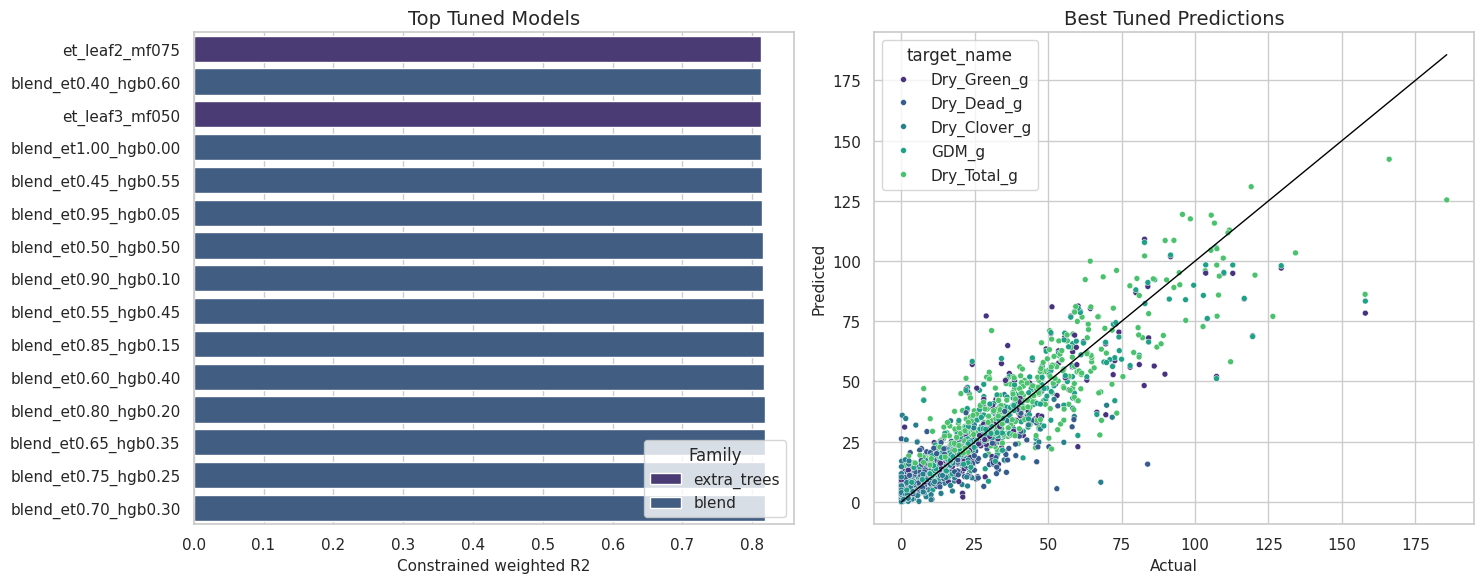

In [12]:
plot_summary = all_summary.head(15).sort_values('constrained_weighted_r2', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=plot_summary, y='experiment', x='constrained_weighted_r2', hue='model_family', dodge=False, ax=axes[0])
axes[0].set_title('Top Tuned Models')
axes[0].set_xlabel('Constrained weighted R2')
axes[0].set_ylabel('')
axes[0].legend(title='Family', loc='lower right')

sns.scatterplot(data=best_oof, x='target', y='prediction', hue='target_name', s=18, ax=axes[1])
limit = max(best_oof['target'].max(), best_oof['prediction'].max())
axes[1].plot([0, limit], [0, limit], color='black', linewidth=1)
axes[1].set_title('Best Tuned Predictions')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
plt.tight_layout()
plt.show()

# 8. Export Artifacts

In [13]:
artifact_files = [
    OUTPUT_DIR / 'tabular_tuning_model_summary.csv',
    OUTPUT_DIR / 'tabular_tuning_model_oof.csv',
    OUTPUT_DIR / 'tabular_tuning_blend_summary.csv',
    OUTPUT_DIR / 'tabular_tuning_blend_oof.csv',
    OUTPUT_DIR / 'tabular_tuning_all_summary.csv',
    OUTPUT_DIR / 'tabular_tuning_per_target.csv',
    OUTPUT_DIR / 'tabular_tuning_segment_error.csv',
    OUTPUT_DIR / 'train_image_features.csv',
    OUTPUT_DIR / 'test_image_features.csv',
]

zip_path = OUTPUT_DIR / 'tabular_tuning_artifacts.zip'
with ZipFile(zip_path, 'w', compression=ZIP_DEFLATED) as zf:
    for path in artifact_files:
        if path.exists():
            zf.write(path, arcname=path.name)
            print(f'Added {path.name}')
        else:
            print(f'Skipped missing file: {path.name}')

print(f'Wrote {zip_path}')

Added tabular_tuning_model_summary.csv
Added tabular_tuning_model_oof.csv
Added tabular_tuning_blend_summary.csv
Added tabular_tuning_blend_oof.csv
Added tabular_tuning_all_summary.csv
Added tabular_tuning_per_target.csv
Added tabular_tuning_segment_error.csv
Added train_image_features.csv
Added test_image_features.csv
Wrote /kaggle/working/tabular_tuning_artifacts.zip


# 9. Promotion Rule

Promote the tuned model only if it beats the current stable constrained CV score around `0.81160` and does not worsen the known hard segments, especially:

- `Dry_Total_g / NSW`
- `GDM_g / NSW`
- `Dry_Green_g / NSW`
- `Dry_Clover_g / WA`

If a blend wins, use the blend only as post-processing from the two fitted model families and apply the biomass constraint only when the selected OOF result validates it.